# Graph analysis using conventional tools and GPU acceleration

Все графики и выводы находятся в конце файла.

## Install packages

In [1]:
# !pip install pyopencl
# !pip install cugraph-cu12

## Imports

In [2]:
import pandas as pd
import os
import time
import numpy as np
import scipy as sk
import networkx as nx
import pyopencl as cl
import cugraph
import cudf
import matplotlib.pyplot as plt
from pathlib import Path

## Dataset

In [3]:
# from google.colab import drive
# drive.mount("./content")

In [4]:
import os

os.chdir("./content/MyDrive/graphs")

In [5]:
# !unzip graphs.zip

In [6]:
graphs_folder_path = Path("./")

graphs_paths = []

for file in graphs_folder_path.iterdir():
    if file.is_file():
        if file.suffix == ".mtx":
            graphs_paths.append(str(file))

print(graphs_paths)

['NotreDame_www.mtx', 'wikipedia-20051105.mtx', 'tmt_sym.mtx', 'vfem.mtx', 'web-Google.mtx', 'amazon0505.mtx', 'flickr.mtx', 'CurlCurl_2.mtx', 'amazon-2008.mtx', 'Stanford.mtx', 'web-Stanford.mtx']


In [7]:
# Словарь для хранения статистик графов
graphs_dct = {
    "graphs": [],
    "n_rows/n_cols": [],
    "n_edges": [],
    "degrees_mean": [],
    "degrees_median": [],
    "degrees_max": []
}

In [8]:
for path in graphs_paths:
    current_graph = sk.io.mmread(path).tocsr()

    n_rows, n_cols = current_graph.shape

    assert n_rows == n_cols, "Take only graphs with n_rows = n_cols!"

    n_edges = current_graph.nnz

    degrees = np.diff(current_graph.indptr)

    degrees_mean, degrees_median, degrees_max = degrees.mean(), np.median(degrees), degrees.max()

    graphs_dct["graphs"].append(current_graph)
    graphs_dct["n_rows/n_cols"].append(n_rows)
    graphs_dct["n_edges"].append(n_edges)
    graphs_dct["degrees_mean"].append(degrees_mean)
    graphs_dct["degrees_median"].append(degrees_median)
    graphs_dct["degrees_max"].append(degrees_max)

    print(f"Graph path: {path}")
    print(f"Shape: {n_rows} x {n_cols}")
    print(f"NNZ: {n_edges}")
    print(f"Density: {n_edges / (n_rows * n_cols):.3e}")
    print(f"Degree: mean={degrees_mean:.2f}, median={degrees_median:.2f}, max={degrees_max}\n\n")

Graph path: NotreDame_www.mtx
Shape: 325729 x 325729
NNZ: 929849
Density: 8.764e-06
Degree: mean=2.85, median=0.00, max=60


Graph path: wikipedia-20051105.mtx
Shape: 1634989 x 1634989
NNZ: 19753078
Density: 7.389e-06
Degree: mean=12.08, median=2.00, max=4970


Graph path: tmt_sym.mtx
Shape: 726713 x 726713
NNZ: 5080961
Density: 9.621e-06
Degree: mean=6.99, median=7.00, max=9


Graph path: vfem.mtx
Shape: 93476 x 93476
NNZ: 1434636
Density: 1.642e-04
Degree: mean=15.35, median=16.00, max=28


Graph path: web-Google.mtx
Shape: 916428 x 916428
NNZ: 5105039
Density: 6.079e-06
Degree: mean=5.57, median=3.00, max=456


Graph path: amazon0505.mtx
Shape: 410236 x 410236
NNZ: 3356824
Density: 1.995e-05
Degree: mean=8.18, median=10.00, max=10


Graph path: flickr.mtx
Shape: 820878 x 820878
NNZ: 9837214
Density: 1.460e-05
Degree: mean=11.98, median=1.00, max=10272


Graph path: CurlCurl_2.mtx
Shape: 806529 x 806529
NNZ: 8921789
Density: 1.372e-05
Degree: mean=11.06, median=11.00, max=13


Graph 

## Анализ

### Прогоняем наивные алгоритмы с семинара на наших графах

In [9]:
def bfs_layers(G, source):
    visited = np.zeros(G.shape[0], dtype=int)
    layers = []
    current_layer = [source]
    visited[source] = 1

    while current_layer:
        layers.append(current_layer)
        next_layer = []
        for node in current_layer:
            for neighbor in G.indices[G.indptr[node]:G.indptr[node+1]]:
                if visited[neighbor] == 0:
                    next_layer.append(neighbor)
                    visited[neighbor] = 1
        current_layer = next_layer

    return layers

In [10]:
def bfs_predecessors(G, source):
    visited = np.zeros(G.shape[0], dtype=int)
    order = np.empty(G.shape[0], dtype=int)
    predecessors = np.full(G.shape[0], -1, dtype=int)
    queue = [source]
    visited[source] = 1

    next_in_order = 0

    while queue:
        node = queue.pop(0)
        order[next_in_order] = node
        next_in_order += 1
        for neighbor in G.indices[G.indptr[node]:G.indptr[node+1]]:  # понял
            if visited[neighbor] == 0:
                queue.append(neighbor)
                visited[neighbor] = 1
                predecessors[neighbor] = node

    order.resize(next_in_order)
    return order, predecessors

In [11]:
results_dct = {
    "naive_layers_cpu": [],
    "naive_layers_wall": [],
    "naive_predecessors_cpu": [],
    "naive_predecessors_wall": [],
}

In [12]:
def calc_time_naive(algorithm_function, algorithm_name):
    for graph in graphs_dct["graphs"]:
        times_cpu = []
        times_wall = []

        for _ in range(10):
            start_wall = time.perf_counter()
            start_cpu = time.process_time()

            naive = algorithm_function(graph, source=0)

            end_wall = time.perf_counter()
            end_cpu = time.process_time()

            times_cpu.append(end_cpu - start_cpu)
            times_wall.append(end_wall - start_wall)

        results_dct[f"naive_{algorithm_name}_cpu"].append(min(times_cpu))
        results_dct[f"naive_{algorithm_name}_wall"].append(min(times_wall))

    return results_dct

In [13]:
results_dct = calc_time_naive(bfs_layers, "layers")

In [14]:
results_dct = calc_time_naive(bfs_predecessors, "predecessors")

In [15]:
# results_dct

### Реализация networkx

In [16]:
results_dct["networkx_layers_cpu"] = []
results_dct["networkx_layers_wall"] = []
results_dct["networkx_predecessors_cpu"] = []
results_dct["networkx_predecessors_wall"] = []

In [17]:
def calc_time_networkx(algorithm_name):
    for graph in graphs_dct["graphs"]:
        current_graph_nx = nx.from_scipy_sparse_array(graph, create_using=nx.DiGraph)

        if algorithm_name == "layers":
            algorithm_func = nx.bfs_layers
        elif algorithm_name == "predecessors":
            algorithm_func = nx.bfs_predecessors
        else:
            raise ValueError("algorithm_name should be either layers or predecessors")

        times_cpu = []
        times_wall = []

        for _ in range(10):
            start_wall = time.perf_counter()
            start_cpu = time.process_time()

            naive = list(algorithm_func(current_graph_nx, 0 if algorithm_name == "predecessors" else [0]))

            end_wall = time.perf_counter()
            end_cpu = time.process_time()

            times_cpu.append(end_cpu - start_cpu)
            times_wall.append(end_wall - start_wall)

        results_dct[f"networkx_{algorithm_name}_cpu"].append(min(times_cpu))
        results_dct[f"networkx_{algorithm_name}_wall"].append(min(times_wall))

    return results_dct

In [18]:
# Run layers from networkx
results_dct = calc_time_networkx("layers")

In [19]:
# Run predecessors from networkx
results_dct = calc_time_networkx("predecessors")

In [20]:
# results_dct["naive_layers_cpu"]

In [21]:
# results_dct["networkx_layers_cpu"]

### SciPy bfs

In [22]:
results_dct["scipy_predecessors_cpu"] = []
results_dct["scipy_predecessors_wall"] = []

In [23]:
for graph in graphs_dct["graphs"]:

    times_cpu = []
    times_wall = []

    for _ in range(10):
        start_wall = time.perf_counter()
        start_cpu = time.process_time()

        sk_order, sk_predecessors = sk.sparse.csgraph.breadth_first_order(graph, 0, directed=True, return_predecessors=True)

        end_wall = time.perf_counter()
        end_cpu = time.process_time()

        times_cpu.append(end_cpu - start_cpu)
        times_wall.append(end_wall - start_wall)

    results_dct[f"scipy_predecessors_cpu"].append(min(times_cpu))
    results_dct[f"scipy_predecessors_wall"].append(min(times_wall))

/usr/local/lib/python3.12/dist-packages/scipy/sparse/_data.py:73: ComplexWarning: Casting complex values to real discards the imaginary part
  self.data.astype(dtype, casting=casting, copy=True),


In [24]:
# results_dct[f"scipy_predecessors_cpu"]

In [25]:
# results_dct[f"networkx_predecessors_cpu"]

### OpenCL bfs

#### Setup

In [26]:
os.environ['PYOPENCL_COMPILER_OUTPUT'] = '1'

In [27]:
# import sys

# !{sys.executable} -m pip install pyopencl

In [28]:
for platform in cl.get_platforms():
    print(f"Platform: {platform.name}")

    for device in platform.get_devices():
        print(f"\tDevice: {device.name}")
        print(f"\t\tType: {cl.device_type.to_string(device.type)}")
        print(f"\t\tCompute Units: {device.max_compute_units}")
        print(f"\t\tGlobal Memory: {device.global_mem_size / (1024**3):.2f} GB")
        print(f"\t\tMax Work Group Size: {device.max_work_group_size}")
        print(f"\t\tVersion: {device.version}")

Platform: NVIDIA CUDA
	Device: Tesla T4
		Type: ALL | GPU
		Compute Units: 40
		Global Memory: 14.56 GB
		Max Work Group Size: 1024
		Version: OpenCL 3.0 CUDA


In [29]:
platform = cl.get_platforms()[0]
print(f"Using platform: {platform.name}")

Using platform: NVIDIA CUDA


In [30]:
context = cl.Context(dev_type=cl.device_type.GPU, properties=[(cl.context_properties.PLATFORM, platform)])
print(f"Context created with devices: {[device.name for device in context.devices]}")

Context created with devices: ['Tesla T4']


In [31]:
queue = cl.CommandQueue(context)
print(f"Command queue created on device: {queue.device.name}")

Command queue created on device: Tesla T4


## BFS Orders/Predecessors в OpenCL

In [32]:
cl_program = cl.Program(context, """
__kernel void bfs_orders(
    __global const int* indptr,
    __global const int* indices,
    const int write_offset,
    __global int* order,
    __global int* predecessors,
    __global int* visited,
    __global int* queue,
    const int queue_size,
    __global int* queue_next,
    __global int* queue_next_size)
{
    int i = get_global_id(0);
    if (i < queue_size) {
        int node = queue[i];
        order[write_offset + i] = node;
        for (int j = indptr[node]; j < indptr[node + 1]; j++) {
            int neighbor = indices[j];
            if (atomic_cmpxchg(&visited[neighbor], 0, 1) == 0) {
                int pos = atomic_inc(queue_next_size);
                queue_next[pos] = neighbor;
                predecessors[neighbor] = node;
            }
        }
    }
}
""").build()

In [33]:
bfs_orders_predecessors_kernel = cl.Kernel(cl_program, "bfs_orders")

In [34]:
def bfs_orders_cl(G_cl, source):
    cl_flags_rw = cl.mem_flags.READ_WRITE

    n = G_cl['shape'][0]
    int_size = np.dtype(np.int32).itemsize

    cl_visited = cl.Buffer(context, cl_flags_rw, size=n * int_size)
    cl_order = cl.Buffer(context, cl_flags_rw, size=n * int_size)
    cl_predecessors = cl.Buffer(context, cl_flags_rw, size=n * int_size)
    cl_queue = cl.Buffer(context, cl_flags_rw, size=n * int_size)
    cl_queue_next = cl.Buffer(context,cl_flags_rw, size=n * int_size)
    cl_queue_next_size = cl.Buffer(context,cl_flags_rw, size=int_size)

    cl.enqueue_fill_buffer(queue, cl_visited, np.int32(0), offset=0, size=n * int_size)
    cl.enqueue_fill_buffer(queue, cl_predecessors, np.int32(-1), offset=0, size=n * int_size)

    cl.enqueue_fill_buffer(queue, cl_visited, np.int32(1), offset=source * int_size, size=int_size)
    cl.enqueue_copy(queue, cl_queue, np.array([source], dtype=np.int32))

    cpu_queue_next_size = np.empty(1, dtype=np.int32)

    queue_size = 1
    write_offset = 0
    while queue_size > 0:
        # обнуляем queue_next_size перед каждым шагом алгоритма
        # он просто будет затирирать после swap'а значения в оригинальном queue (который теперь new_queue)
        # благодаря тому что мы снова идем с 0
        cl.enqueue_fill_buffer(queue, cl_queue_next_size, np.int32(0), offset=0, size=int_size)

        bfs_orders_predecessors_kernel(queue,
            (queue_size,), None,
            G_cl['indptr'], G_cl['indices'],
            np.int32(write_offset),
            cl_order, cl_predecessors,
            cl_visited,
            cl_queue, np.int32(queue_size),
            cl_queue_next, cl_queue_next_size)

        write_offset += queue_size  # вначале прибавляем 1 так как начали из одной вершины

        cl.enqueue_copy(queue, cpu_queue_next_size, cl_queue_next_size)
        queue_size = cpu_queue_next_size[0]  # копируем на cpu размер/кол-во вершин которые мы обойдем в следующей итерации цикла

        if queue_size > 0:
            cl_queue, cl_queue_next = cl_queue_next, cl_queue

    order = np.empty(n, dtype=np.int32)
    predecessors = np.empty(n, dtype=np.int32)
    cl.enqueue_copy(queue, order, cl_order)
    cl.enqueue_copy(queue, predecessors, cl_predecessors)
    return order, predecessors

In [35]:
# bfs_orders_predecessors_kernel = cl.Kernel(cl_program, "bfs_orders")

In [36]:
results_dct["gpu_predecessors_wall"] = []

for graph in graphs_dct["graphs"]:
    # indices - по идее список всех соседей по порядку
    # indptr - хранит список того с какого индекса в indices начинаются соседи для конкретной вершины
    G_cl = dict(
        # indptr[v] = с какой позиции в indices начинаются соседи вершины v
        indptr=cl.Buffer(context, cl.mem_flags.READ_ONLY | cl.mem_flags.COPY_HOST_PTR, hostbuf=graph.indptr.astype(np.int32)),
        # все соседи всех вершин подряд, склеенные в один плоский массив
        indices=cl.Buffer(context, cl.mem_flags.READ_ONLY | cl.mem_flags.COPY_HOST_PTR, hostbuf=graph.indices.astype(np.int32)),
        # веса если нужны
        data=cl.Buffer(context, cl.mem_flags.READ_ONLY | cl.mem_flags.COPY_HOST_PTR, hostbuf=graph.data.real.astype(np.float32)),
        shape=np.array(graph.shape, dtype=np.int32))

    times = []
    for _ in range(10):
        # queue.finish()

        start_time = time.perf_counter()
        bfs_orders_cl(G_cl, source=0)

        # queue.finish()
        end_time = time.perf_counter()

        times.append(end_time - start_time)

    results_dct["gpu_predecessors_wall"].append(min(times))

In [37]:
results_dct["gpu_predecessors_wall"]

[0.024787345000731875,
 0.028610067998670274,
 0.07508701799997652,
 0.005970005999188288,
 0.009857715998805361,
 0.0062865629988664296,
 0.014580679000573582,
 0.016002888998627895,
 0.008423625999057549,
 0.0015566519996355055,
 0.003117917000054149]

## BFS_LAYERS в OpenCL

In [38]:
cl_program_layers = cl.Program(context, """
__kernel void bfs_layers(
    __global const int* indptr,
    __global const int* indices,
    __global int* visited,
    __global int* queue,
    const int queue_size,
    __global int* queue_next,
    __global int* queue_next_size)
{
    int i = get_global_id(0);
    if (i < queue_size) {
        int node = queue[i];
        for (int j = indptr[node]; j < indptr[node + 1]; j++) {
            int neighbor = indices[j];
            if (atomic_cmpxchg(&visited[neighbor], 0, 1) == 0) {
                int pos = atomic_inc(queue_next_size);
                queue_next[pos] = neighbor;
            }
        }
    }
}
""").build()

In [39]:
bfs_layers_kernel = cl.Kernel(cl_program_layers, "bfs_layers")

In [40]:
def bfs_layers_cl(G_cl, source):
    cl_flags_rw = cl.mem_flags.READ_WRITE

    n = G_cl['shape'][0]
    int_size = np.dtype(np.int32).itemsize

    cl_visited = cl.Buffer(context, cl_flags_rw, size=n * int_size)
    cl_queue = cl.Buffer(context, cl_flags_rw, size=n * int_size)
    cl_queue_next = cl.Buffer(context,cl_flags_rw, size=n * int_size)
    cl_queue_next_size = cl.Buffer(context,cl_flags_rw, size=int_size)

    cl.enqueue_fill_buffer(queue, cl_visited, np.int32(0), offset=0, size=n * int_size)

    cl.enqueue_fill_buffer(queue, cl_visited, np.int32(1), offset=source * int_size, size=int_size)
    cl.enqueue_copy(queue, cl_queue, np.array([source], dtype=np.int32))

    cpu_queue_next_size = np.empty(1, dtype=np.int32)

    queue_size = 1

    layers = []

    layers.append(np.array([source], dtype=np.int32))

    while queue_size > 0:
        # обнуляем queue_next_size перед каждым шагом алгоритма
        # он просто будет затирирать после swap'а значения в оригинальном queue (который теперь new_queue)
        # благодаря тому что мы снова идем с 0
        cl.enqueue_fill_buffer(queue, cl_queue_next_size, np.int32(0), offset=0, size=int_size)

        bfs_layers_kernel(queue,
            (queue_size,), None,
            G_cl['indptr'], G_cl['indices'],
            cl_visited,
            cl_queue, np.int32(queue_size),
            cl_queue_next, cl_queue_next_size)

        cl.enqueue_copy(queue, cpu_queue_next_size, cl_queue_next_size)
        queue_size = cpu_queue_next_size[0]  # копируем на cpu размер/кол-во вершин которые мы обойдем в следующей итерации цикла

        if queue_size > 0:
            current_layers = np.empty(queue_size, dtype=np.int32)
            cl.enqueue_copy(queue, current_layers, cl_queue_next)
            layers.append(current_layers)
            cl_queue, cl_queue_next = cl_queue_next, cl_queue

    return layers

In [41]:
results_dct["gpu_layers_wall"] = []

for graph in graphs_dct["graphs"]:
    # indices - по идее список всех соседей по порядку
    # indptr - хранит список того с какого индекса в indices начинаются соседи для конкретной вершины
    G_cl = dict(
        # indptr[v] = с какой позиции в indices начинаются соседи вершины v
        indptr=cl.Buffer(context, cl.mem_flags.READ_ONLY | cl.mem_flags.COPY_HOST_PTR, hostbuf=graph.indptr.astype(np.int32)),
        # все соседи всех вершин подряд, склеенные в один плоский массив
        indices=cl.Buffer(context, cl.mem_flags.READ_ONLY | cl.mem_flags.COPY_HOST_PTR, hostbuf=graph.indices.astype(np.int32)),
        # веса если нужны
        data=cl.Buffer(context, cl.mem_flags.READ_ONLY | cl.mem_flags.COPY_HOST_PTR, hostbuf=graph.data.real.astype(np.float32)),
        shape=np.array(graph.shape, dtype=np.int32))

    times = []
    for _ in range(10):
        # queue.finish()

        start_time = time.perf_counter()
        example_layers = bfs_layers_cl(G_cl, source=0)
        # print(example_layers)

        # queue.finish()
        end_time = time.perf_counter()

        times.append(end_time - start_time)

    results_dct["gpu_layers_wall"].append(min(times))

In [42]:
# example_layers

In [43]:
# example_arr = graph.todense()[0]

## CuGraph

In [44]:
results_dct["cugraph_predecessors_wall"] = []

for graph in graphs_dct["graphs"]:
    current_graph_coo = graph.tocoo()

    edges = cudf.DataFrame({
        'src': current_graph_coo.row,
        'dst': current_graph_coo.col
    })

    G = cugraph.Graph(directed=True)
    G.from_cudf_edgelist(edges, source='src', destination='dst')

    times = []

    for _ in range(10):
        start_time = time.perf_counter()

        res = cugraph.bfs(G, start=0)

        end_time = time.perf_counter()

        times.append(end_time - start_time)

    results_dct["cugraph_predecessors_wall"].append(min(times))

## Записываем результаты в DataFrame


In [45]:
new_graphs_dct = {k: v for k, v in graphs_dct.items() if k != "graphs"}
new_graphs_dct.keys()

results_df = pd.DataFrame(new_graphs_dct | results_dct)

graphs_stats_cols = ["n_rows/n_cols", "n_edges", "degrees_mean", "degrees_median", "degrees_max"]

results_df.head(10)[graphs_stats_cols + ["naive_layers_wall", "networkx_layers_wall", "gpu_layers_wall"]]

,n_rows/n_cols,n_edges,degrees_mean,degrees_median,degrees_max,naive_layers_wall,networkx_layers_wall,gpu_layers_wall
0,325729,929849,2.854671,0.0,60,0.295530,0.119282,0.021827
1,1634989,19753078,12.081475,2.0,4970,6.399014,4.296833,0.025049
2,726713,5080961,6.991702,7.0,9,2.198227,0.917511,0.075380
3,93476,1434636,15.347640,16.0,28,0.433957,0.162797,0.007218
4,916428,5105039,5.570584,3.0,456,1.936404,1.215756,0.008986
5,410236,3356824,8.182666,10.0,10,1.420525,0.827558,0.006348
6,820878,9837214,11.983771,1.0,10272,3.411364,1.665188,0.013617
7,806529,8921789,11.061957,11.0,13,3.156543,1.421026,0.019747
8,735323,5158388,7.015132,10.0,10,2.355726,1.414916,0.007642
9,281903,2312497,8.203166,2.0,38606,0.000091,0.000006,0.000713


## Визуализируем результаты и сделаем выводы

In [46]:
from itertools import cycle

def plot_graphs(df: pd.DataFrame, dep_col: str, algorithm_name: str) -> None:
    df = results_df.sort_values("n_edges")

    fig, ax = plt.subplots(figsize=(10, 6))

    color_cycle = cycle(['#D85A30', '#2E86AB', '#A23B72', '#F18F01', '#6B9E78', '#8E44AD'])
    marker = cycle(["o", "s", "^"])

    cur_cols = []
    for col in df.columns:
        if col.endswith("_wall"):
            if algorithm_name in col:
                cur_cols.append(col)

    for col in cur_cols:
        ax.plot(df[dep_col], df[col],
            marker=next(marker), label="_".join(col.split("_")[:-2]), color=next(color_cycle))

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(f"{dep_col} (log)")
    ax.set_ylabel("wall time, sec (log)")
    ax.set_title(f"BFS {algorithm_name}")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)
    ax.legend()

    plt.tight_layout()
    plt.show()

Вначале посмотрим на зависимость от кол-ва ребер.

**График зависимости времени работы разных predecessors - алгоритмов от n_edges**

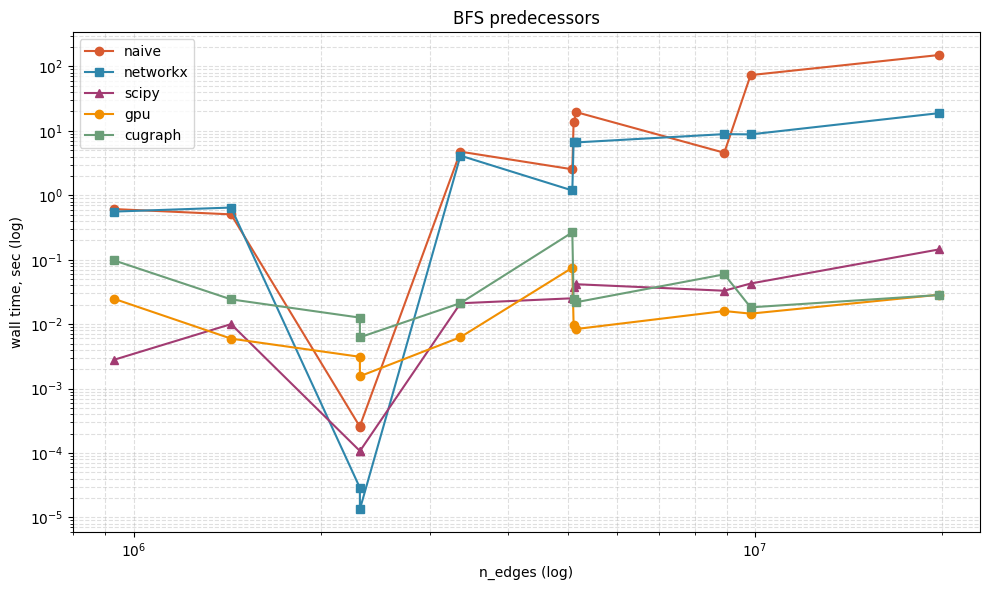

In [47]:
plot_graphs(results_df, "n_edges", "predecessors")

- Для графов с небольшим кол-вом ребер быстрее всего scipy реализация, gpu реализации (через opencl и cugraph) уступают, самые медленные - naive и networkx.

- Почти во всех случаях naive и networkx медленее всех остальных реализаций.

- Для графов с n_edges << 10^7 scipy быстрее cugraph.

- Почти для всех n_edges реализация через opencl быстрее cugraph реализации.

- С ростом n_edges разница во времени работы naive и networkx растет по сравнению со scipy и gpu-реализациями.

- Начиная с ~ 10^7 рёбер GPU-реализации стабильно опережают scipy

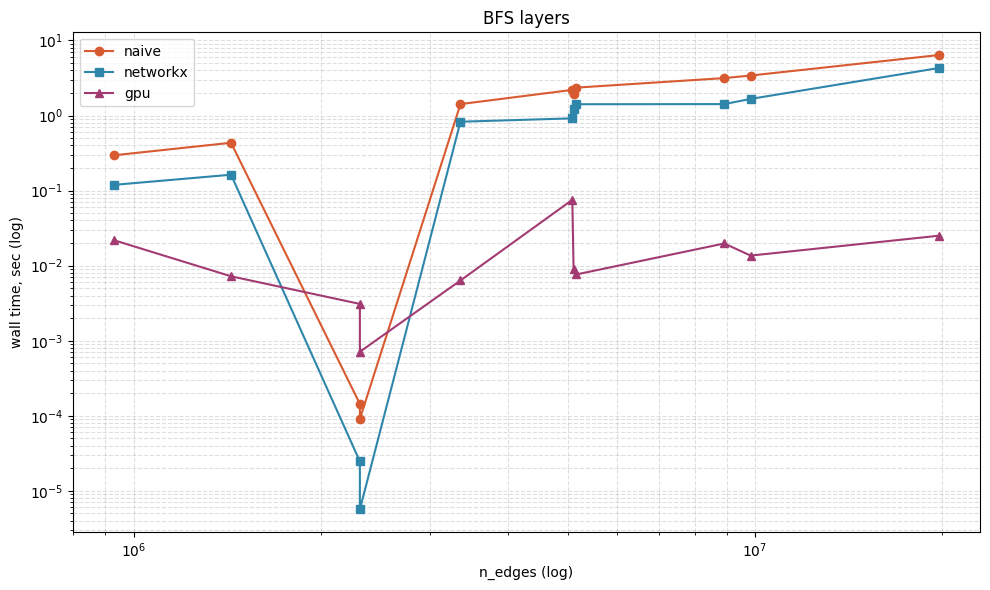

In [48]:
plot_graphs(results_df, "n_edges", "layers")

Для layers я не использовал cugraph, scipy

- gpu реализация быстрее naive, networkx почти для всех n_edges

- networkx быстрее naive

**График зависимости времени работы разных layers - алгоритмов от n_edges**

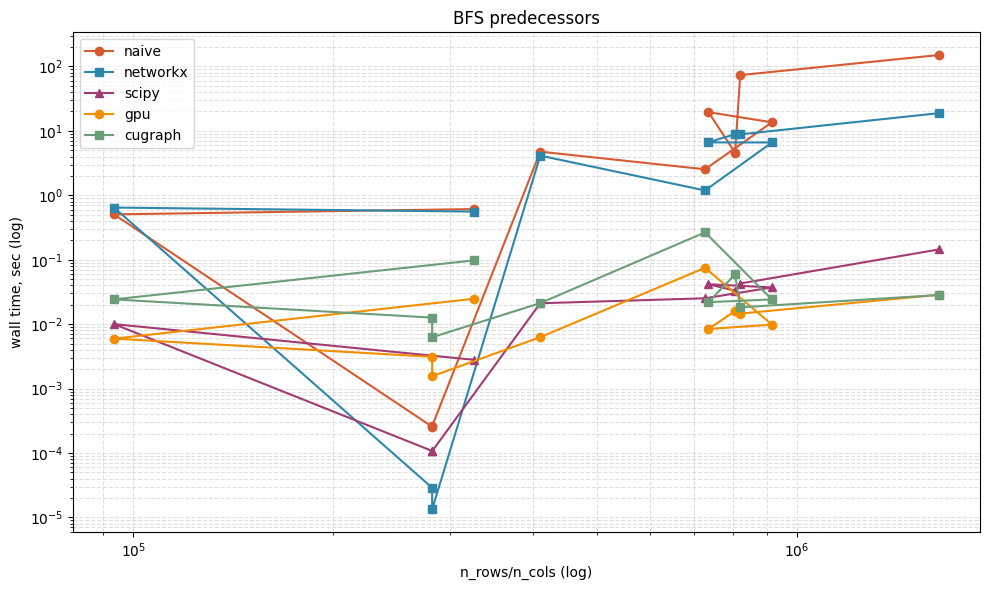

In [49]:
plot_graphs(results_df, "n_rows/n_cols", "predecessors")

- На графах с n_rows > 5 * 10^5 naive и networkx сильно отстают от остальных реализаций - разрыв достигает 3 - 4 порядков.

- gpu (opencl) реализация почти всегда быстрее cugraph, разрыв особенно заметен на маленьких графах.

- scipy на больших графах (n_rows > 10 ^ 6) проигрывает gpu-реализациям, хотя на средних держится с ними наравне.

**Главный вывод:** с помощью GPU (используя cugraph или OpenCL) можно добиться существенного улучшения в скорости работы алгоритма BFS